## Data Preprocessing

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./data.csv')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [81]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X, y)
X_poly

array([[1.00000000e+00, 4.16467595e+01, 1.73445258e+03],
       [1.00000000e+00, 4.27510817e+01, 1.82765499e+03],
       [1.00000000e+00, 4.37160330e+01, 1.91109154e+03],
       [1.00000000e+00, 4.46466890e+01, 1.99332684e+03],
       [1.00000000e+00, 4.52041274e+01, 2.04341314e+03],
       [1.00000000e+00, 4.78137691e+01, 2.28615652e+03],
       [1.00000000e+00, 4.97630588e+01, 2.47636202e+03],
       [1.00000000e+00, 5.11595089e+01, 2.61729535e+03],
       [1.00000000e+00, 5.24795616e+01, 2.75410439e+03],
       [1.00000000e+00, 5.24814912e+01, 2.75430692e+03],
       [1.00000000e+00, 5.36419299e+01, 2.87745664e+03],
       [1.00000000e+00, 5.45459974e+01, 2.97526583e+03],
       [1.00000000e+00, 5.46723608e+01, 2.98906703e+03],
       [1.00000000e+00, 5.47883564e+01, 3.00176400e+03],
       [1.00000000e+00, 5.59739026e+01, 3.13307777e+03],
       [1.00000000e+00, 5.69871289e+01, 3.24753286e+03],
       [1.00000000e+00, 6.07023985e+01, 3.68478119e+03],
       [1.00000000e+00, 6.32983

In [83]:
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


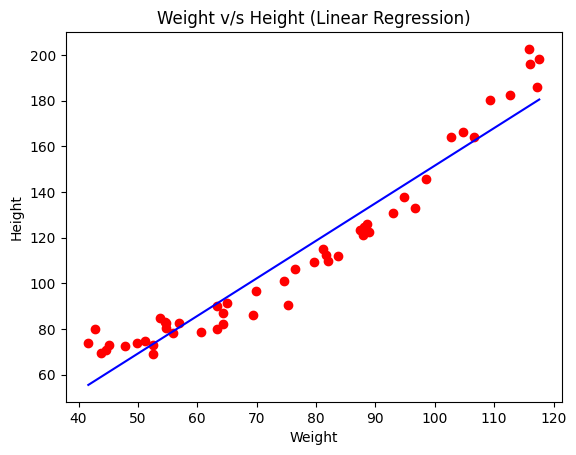

In [84]:
plt.title("Weight v/s Height (Linear Regression)")
plt.xlabel("Weight")
plt.ylabel("Height")

plt.scatter(X, y, color="red")
plt.plot(X, lin_reg.predict(X), color="blue")

plt.show()

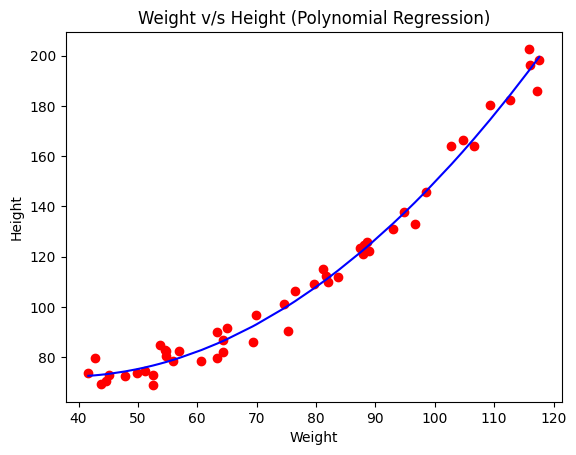

In [85]:
plt.title("Weight v/s Height (Polynomial Regression)")
plt.xlabel("Weight")
plt.ylabel("Height")

plt.scatter(X, y, color="red")
plt.plot(X, lin_reg_2.predict(X_poly), color="blue")

plt.show()

In [86]:
value = [[105]]

ans1 = lin_reg.predict(value)
ans2 = lin_reg_2.predict(poly_reg.fit_transform(value))

print(f"Height at weight = 120 (Linear Regression) : {ans1}")
print(f"Height at weight = 120 (Polynomial Regression) : {ans2}")

Height at weight = 120 (Linear Regression) : [159.76270795]
Height at weight = 120 (Polynomial Regression) : [162.56069252]


In [87]:
from sklearn.metrics import r2_score

r2_score(y, lin_reg_2.predict(X_poly))

0.9865401835690221